# Denizli Kiralık Ev Tahmini- Web Scrapping - Regression

##### İnternetten Denizli'deki kiralık daire fiyatlarını çekerek fiyat tahmini modeli

#### Import packages

In [4]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import time
import random
import warnings 
warnings.filterwarnings('ignore')

### Web Scrapping Codes

###### Web Scrapping kodlarını satır içi yorum haline getirdim, inline commentleri kaldırmak için ctrl + a yaparak satırdaki tüm kodları seçip ctrl + / tuşuna basarak kaldırabilirsiniz

In [7]:
headers = {"User-Agent": "Mozilla/5.0"}

In [8]:
base_url = "https://www.emlakjet.com/kiralik-konut/denizli/"
page=[f"{base_url}{i}" for i in range(1,49)]

print(page)

In [9]:
# Kiralık ev ilanlarının linklerini tutmak için boş bir liste oluşturuyoruz
house = []

# 1'den 44'e kadar tüm sayfaları sırayla ziyaret ediyoruz
for url in page:
    # Sayfaya tarayıcı gibi davranarak GET isteği gönderiyoruz
    response = requests.get(url, headers=headers)

    # Sayfa başarıyla yüklendiyse (HTTP 200 durumu)
    if response.status_code == 200:
        # Sayfa içeriğini BeautifulSoup ile HTML olarak parse ediyoruz
        soup = BeautifulSoup(response.content, "html.parser")

        # Sayfadaki tüm ilan kutularını (listingleri) seçiyoruz
        listings = soup.find_all("div", class_="styles_listingWrapper__I0H_l")

        # Her bir ilan kutusunu tek tek inceliyoruz
        for listing in listings:
            # Eğer ilan kutusu "Aramayı Kaydet" butonunu içeriyorsa, geçiyoruz
            if listing.find("div", class_="styles_saveSeasrchWrapper__gdgdi"):
                continue
            # Eğer ilan kutusu başka bir kapsayıcıysa (örneğin önerilen kutular), geçiyoruz
            elif listing.find("div", class_="styles_container__6p6oI"):
                continue
            # Eğer ilan kutusu reklam slotuysa, yine geçiyoruz
            elif listing.find("div", class_="styles_adSlotWrap__ARrCX"):
                continue

            # İlan bağlantısını (linkini) içeren <a> etiketi bulunuyor
            link_tag = listing.find("a", href=True)

            # Eğer geçerli bir bağlantı etiketi varsa
            if link_tag:
                # Bağlantının başına domain ekleyerek tam bağlantı oluşturuyoruz
                full_link = "https://www.emlakjet.com/" + link_tag["href"]
                
                # Bağlantıyı house listesine ekliyoruz
                house.append(full_link)

In [10]:
import pandas as pd       
import numpy as np        

# Tüm ev ilanlarının detaylarını tutacağımız boş bir liste
house_data = []

# Daha önce elde ettiğimiz tüm ilan bağlantılarını tek tek dolaşıyoruz
for house_url in house:
    # Her ilan linkine GET isteği gönderiyoruz (headers ile tarayıcı gibi davranarak)
    response = requests.get(house_url, headers=headers)

    # Sayfa başarıyla yüklendiyse
    if response.status_code == 200:
        # Sayfa içeriğini BeautifulSoup ile HTML olarak parse ediyoruz
        soup = BeautifulSoup(response.content, "html.parser")

        # Her bir ev için özellikleri tutacağımız sözlük
        house_info = {}

        # Fiyat bilgisini içeren <span> etiketini buluyoruz
        price_span = soup.find("span", class_="styles_price__6zH_9")
        # Fiyat varsa metnini al, yoksa np.nan ata
        price = price_span.get_text(strip=True) if price_span else np.nan

        # Konum bilgisini içeren <span> etiketini buluyoruz
        location_span = soup.find("span", class_="styles_location__Y01SC")
        if location_span:
            # Metni al ve "-" işaretine göre parçala (örneğin: "Türkiye - Denizli - Pamukkale")
            location_text = location_span.get_text(strip=True)
            location_parts = location_text.split("-")
            # İlçe ve mahalle bilgisini birleştirerek al (örneğin: "Pamukkale - Mehmetçik Mahallesi")
            location = "-".join(location_parts[1:3]) if len(location_parts) >= 2 else np.nan
        else:
            # Konum bulunamazsa boş (nan) olarak geç
            location = np.nan

        # Özelliklerin (m², oda sayısı, bina yaşı vs.) yer aldığı bölümü bul
        features_div = soup.find("div", class_="styles_inner__sV8Bk")

        if features_div:
            # İçindeki <li> etiketlerini (özellikleri) bul
            li_tags = features_div.find_all("li")
            
            # Her bir özellik için
            for li in li_tags:
                # İçindeki <span> etiketlerini bul (genellikle 2 tane: başlık ve değer)
                spans = li.find_all("span")
                if len(spans) == 2:
                    # Anahtar ve değeri ayıkla ve temizle
                    key = spans[0].get_text(strip=True)
                    value = spans[1].get_text(strip=True)
                    # Sözlüğe ekle (örneğin: "Brüt m²": "120")
                    house_info[key] = value

            # Fiyat, konum ve linki de sözlüğe ekliyoruz
            house_info["Price"] = price
            house_info["Location"] = location
            house_info["link"] = house_url

            # Bu evin tüm bilgilerini ana listeye ekliyoruz
            house_data.append(house_info)


In [11]:
df = pd.DataFrame(house_data)

In [12]:
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows",200)

In [13]:
df.to_csv("HDenizli_kiralıkEv_data.csv")

In [14]:
df = pd.read_csv("HDenizli_kiralıkEv_data.csv")

### Exploratory Data Analysis - Data Imputation - Feature Engineering

In [16]:
df.head()

,Unnamed: 0,İlan Numarası,İlan Oluşturma Tarihi,İlan Güncelleme Tarihi,Türü,Kategorisi,Tipi,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Kullanım Durumu,Eşya Durumu,Tapu Durumu,Site İçerisinde,Takas,Banyo Sayısı,Fiyat Durumu,Price,Location,link,Aidat,Depozito,Balkon Durumu,Balkon Sayısı,Görüntülü Gezilebilir mi?,Ada,Parsel,Balkon Tipi,Yapı Durumu,Yapı Tipi,WC Sayısı,Banyo Metrekare,Balkon Metrekare,Salon Metrekare,WC Metrekare
0,0,17110646,04 Nisan 2025,04 Nisan 2025,Konut,Kiralık,Daire,110 m²,115 m²,2+1,16-20,Bahçe Katı,2,Kombi Doğalgaz,Boş,Boş,Kat Mülkiyeti,Hayır,Yok,1,Genel Fiyat,13.000TL,Merkezefendi - Bereketler Mahallesi,https://www.emlakjet.com//ilan/karadag-gayrime...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,17109845,04 Nisan 2025,04 Nisan 2025,Konut,Kiralık,Daire,50 m²,57 m²,1+1,5-10,2.Kat,3,Yerden Isıtma,Boş,Eşyalı,Kat İrtifakı,Hayır,Yok,1,Genel Fiyat,10.000TL,Pamukkale - İncilipınar Mahallesi,https://www.emlakjet.com//ilan/atlantisten-inc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,17109086,04 Nisan 2025,04 Nisan 2025,Konut,Kiralık,Daire,85 m²,95 m²,2+1,5-10,3.Kat,4,Merkezi Doğalgaz,Boş,NaN,Kat Mülkiyeti,Evet,NaN,1,Genel Fiyat,15.500TL,Merkezefendi - Kayalar Mahallesi,https://www.emlakjet.com//ilan/redstone-myra-d...,790 TL,15500 TL,Var,1,Evet,8189.00,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,17108098,04 Nisan 2025,04 Nisan 2025,Konut,Kiralık,Daire,120 m²,128 m²,3+1,11-15,4.Kat,7,Doğalgaz Sobalı,Boş,Boş,Kat Mülkiyeti,Evet,NaN,1,Genel Fiyat,16.000TL,Pamukkale - 15 Mayıs Mahallesi,https://www.emlakjet.com//ilan/31-120-mtr-1710...,500 TL,1 TL,Var,1,NaN,222.00,1.00,Açık Balkon,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,17108046,04 Nisan 2025,04 Nisan 2025,Konut,Kiralık,Daire,40 m²,45 m²,1+1,0 (Yeni),3.Kat,3,Yerden Isıtma,Boş,Eşyalı,Kat Mülkiyeti,Hayır,NaN,1,Genel Fiyat,15.000TL,Pamukkale - Zeytinköy Mahallesi,https://www.emlakjet.com//ilan/pamukkale-unive...,NaN,15000 TL,Var,1,Hayır,3702.00,10.00,Açık Balkon,Sıfır,Betonarme,1.00,NaN,NaN,NaN,NaN


In [17]:
df.shape

(1200, 39)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 1200 non-null   int64  
 1   İlan Numarası              1200 non-null   int64  
 2   İlan Oluşturma Tarihi      1200 non-null   object 
 3   İlan Güncelleme Tarihi     1200 non-null   object 
 4   Türü                       1200 non-null   object 
 5   Kategorisi                 1200 non-null   object 
 6   Tipi                       1200 non-null   object 
 7   Net Metrekare              1199 non-null   object 
 8   Brüt Metrekare             1200 non-null   object 
 9   Oda Sayısı                 1200 non-null   object 
 10  Binanın Yaşı               1200 non-null   object 
 11  Bulunduğu Kat              1194 non-null   object 
 12  Binanın Kat Sayısı         1200 non-null   int64  
 13  Isıtma Tipi                1200 non-null   objec

In [19]:
df.value_counts("Tipi")

Tipi
Daire        1183
Residence      11
Villa           6
Name: count, dtype: int64

In [20]:
df.value_counts("Isıtma Tipi")

Isıtma Tipi
Kombi Doğalgaz         741
Yerden Isıtma          288
Merkezi Doğalgaz       105
Merkezi (Pay Ölçer)     37
Sobalı                   7
Kat Kaloriferi           6
Klimalı                  6
Doğalgaz Sobalı          3
Jeotermal                2
Kombi Fueloil            2
Elektrikli Radyatör      1
Isı Pompası              1
Isıtma Yok               1
Name: count, dtype: int64

In [21]:
df.value_counts("Yapı Tipi")

Yapı Tipi
Betonarme    126
Name: count, dtype: int64

In [22]:
df.value_counts("Yapı Durumu")

Yapı Durumu
İkinci El    108
Sıfır         24
Name: count, dtype: int64

In [23]:
df.value_counts("Balkon Tipi")

Balkon Tipi
Açık Balkon                   97
Kapalı Balkon                  9
Açık Teras                     8
Açık Balkon, Kapalı Balkon     6
Fransız Balkon                 3
Kapalı Teras                   1
Name: count, dtype: int64

In [24]:
df.value_counts("Kullanım Durumu")

Kullanım Durumu
Boş                     1180
Kiracı Oturuyor           19
Mülk Sahibi Oturuyor       1
Name: count, dtype: int64

In [25]:
df.value_counts("Eşya Durumu")

Eşya Durumu
Eşyalı    437
Boş       367
Name: count, dtype: int64

In [26]:
df.value_counts("Site İçerisinde")

Site İçerisinde
Hayır    1080
Evet      120
Name: count, dtype: int64

In [27]:
df.value_counts("Fiyat Durumu")

Fiyat Durumu
Genel Fiyat    1180
Birim Fiyat      20
Name: count, dtype: int64

In [28]:
df[(df["Fiyat Durumu"] == "Birim Fiyat")].head(3)

,Unnamed: 0,İlan Numarası,İlan Oluşturma Tarihi,İlan Güncelleme Tarihi,Türü,Kategorisi,Tipi,Net Metrekare,Brüt Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Kullanım Durumu,Eşya Durumu,Tapu Durumu,Site İçerisinde,Takas,Banyo Sayısı,Fiyat Durumu,Price,Location,link,Aidat,Depozito,Balkon Durumu,Balkon Sayısı,Görüntülü Gezilebilir mi?,Ada,Parsel,Balkon Tipi,Yapı Durumu,Yapı Tipi,WC Sayısı,Banyo Metrekare,Balkon Metrekare,Salon Metrekare,WC Metrekare
53,53,17076611,26 Mart 2025,26 Mart 2025,Konut,Kiralık,Daire,100 m²,110 m²,2+1,5-10,2.Kat,4,Kombi Doğalgaz,Boş,Boş,Kat Mülkiyeti,Hayır,NaN,1,Birim Fiyat,14.000TL,Merkezefendi - Gümüşçay Mahallesi,https://www.emlakjet.com//ilan/tercih-den-gumu...,NaN,NaN,Var,1,NaN,296.00,12.00,Açık Balkon,NaN,NaN,2.00,NaN,NaN,NaN,NaN
77,77,17064714,24 Mart 2025,02 Nisan 2025,Konut,Kiralık,Daire,45 m²,50 m²,1+1,4,2.Kat,4,Kombi Doğalgaz,Boş,Eşyalı,Kat Mülkiyeti,Hayır,NaN,1,Birim Fiyat,13.000TL,Merkezefendi - Adalet Mahallesi,https://www.emlakjet.com//ilan/erkus-gyo-dan-a...,NaN,13000 TL,Var,1,Evet,347.00,6.00,Açık Balkon,İkinci El,Betonarme,NaN,NaN,NaN,NaN,NaN
191,191,16998001,11 Mart 2025,11 Mart 2025,Konut,Kiralık,Daire,65 m²,69 m²,2+1,16-20,2.Kat,3,Kombi Doğalgaz,Boş,NaN,Kat Mülkiyeti,Hayır,NaN,2,Birim Fiyat,14.500TL,Merkezefendi - Değirmenönü Mahallesi,https://www.emlakjet.com//ilan/kaan-gayrimenku...,NaN,NaN,Var,1,NaN,1503.00,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df.value_counts("Location")

Location
Pamukkale - Zeytinköy Mahallesi               131
Pamukkale - Kınıklı Mahallesi                  88
Pamukkale - Asmalıevler Mahallesi              80
Pamukkale - Yunusemre Mahallesi                79
Pamukkale - Siteler Mahallesi                  49
Merkezefendi - Değirmenönü Mahallesi           47
Merkezefendi - Şemikler Mahallesi              45
Merkezefendi - Adalet Mahallesi                41
Pamukkale - İncilipınar Mahallesi              40
Pamukkale - Mehmetçik Mahallesi                39
Merkezefendi - Sırakapılar Mahallesi           35
Pamukkale - Atalar Mahallesi                   33
Merkezefendi - Karahasanlı Mahallesi           30
Pamukkale - 15 Mayıs Mahallesi                 27
Pamukkale - Kuşpınar Mahallesi                 24
Merkezefendi - Yenişafak Mahallesi             24
Merkezefendi - Çakmak Mahallesi                24
Merkezefendi - Karaman Mahallesi               23
Merkezefendi - Selçuk Bey Mahallesi            21
Merkezefendi - Akkonak Mahallesi         

In [30]:
df.value_counts("Parsel")

Parsel
2.00       32
3.00       27
1.00       22
6.00       21
4.00       20
7.00       17
10.00      16
8.00       13
9.00       11
11.00      11
12.00      10
5.00        9
18.00       8
17.00       6
26.00       6
20.00       5
1914.00     5
13.00       5
16.00       4
19.00       4
23.00       4
15.00       3
22.00       3
24.00       3
27.00       2
28.00       2
21.00       2
25.00       2
14.00       1
35.00       1
105.00      1
141.00      1
164.00      1
175.00      1
213.00      1
273.00      1
321.00      1
481.00      1
1165.00     1
30.00       1
Name: count, dtype: int64

In [31]:
df.value_counts("Oda Sayısı")

Oda Sayısı
1+1       461
2+1       330
3+1       295
Stüdyo     29
4+1        25
2.5+1      16
2+0        12
3.5+1       9
1 Oda       6
1.5+1       6
5+1         4
5+2         3
3+2         2
3+0         1
7+3         1
Name: count, dtype: int64

In [32]:
df.isnull().sum()

Unnamed: 0                      0
İlan Numarası                   0
İlan Oluşturma Tarihi           0
İlan Güncelleme Tarihi          0
Türü                            0
Kategorisi                      0
Tipi                            0
Net Metrekare                   1
Brüt Metrekare                  0
Oda Sayısı                      0
Binanın Yaşı                    0
Bulunduğu Kat                   6
Binanın Kat Sayısı              0
Isıtma Tipi                     0
Kullanım Durumu                 0
Eşya Durumu                   396
Tapu Durumu                     0
Site İçerisinde                 0
Takas                         453
Banyo Sayısı                    0
Fiyat Durumu                    0
Price                           0
Location                        0
link                            0
Aidat                        1072
Depozito                     1041
Balkon Durumu                 981
Balkon Sayısı                1042
Görüntülü Gezilebilir mi?    1113
Ada           

In [33]:
# Önemsiz, tekrarlanabilir, çok fazla boş veri içeren sütunları kaldırıyoruz
df.drop(["İlan Oluşturma Tarihi","Türü","Kategorisi","Brüt Metrekare",
         "Kullanım Durumu","Takas","Fiyat Durumu","link",
         "Aidat","Balkon Durumu","Görüntülü Gezilebilir mi?","Ada",
         "Parsel","Yapı Tipi","Banyo Metrekare",
         "Balkon Metrekare","Salon Metrekare","WC Metrekare"], axis=1, inplace=True)

In [34]:
df.head()

,Unnamed: 0,İlan Numarası,İlan Güncelleme Tarihi,Tipi,Net Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Eşya Durumu,Tapu Durumu,Site İçerisinde,Banyo Sayısı,Price,Location,Depozito,Balkon Sayısı,Balkon Tipi,Yapı Durumu,WC Sayısı
0,0,17110646,04 Nisan 2025,Daire,110 m²,2+1,16-20,Bahçe Katı,2,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,13.000TL,Merkezefendi - Bereketler Mahallesi,NaN,NaN,NaN,NaN,NaN
1,1,17109845,04 Nisan 2025,Daire,50 m²,1+1,5-10,2.Kat,3,Yerden Isıtma,Eşyalı,Kat İrtifakı,Hayır,1,10.000TL,Pamukkale - İncilipınar Mahallesi,NaN,NaN,NaN,NaN,NaN
2,2,17109086,04 Nisan 2025,Daire,85 m²,2+1,5-10,3.Kat,4,Merkezi Doğalgaz,NaN,Kat Mülkiyeti,Evet,1,15.500TL,Merkezefendi - Kayalar Mahallesi,15500 TL,1,NaN,NaN,NaN
3,3,17108098,04 Nisan 2025,Daire,120 m²,3+1,11-15,4.Kat,7,Doğalgaz Sobalı,Boş,Kat Mülkiyeti,Evet,1,16.000TL,Pamukkale - 15 Mayıs Mahallesi,1 TL,1,Açık Balkon,NaN,NaN
4,4,17108046,04 Nisan 2025,Daire,40 m²,1+1,0 (Yeni),3.Kat,3,Yerden Isıtma,Eşyalı,Kat Mülkiyeti,Hayır,1,15.000TL,Pamukkale - Zeytinköy Mahallesi,15000 TL,1,Açık Balkon,Sıfır,1.00


In [35]:
df.drop(["Yapı Durumu","Depozito"], axis=1, inplace=True)

In [36]:
df.shape

(1200, 19)

In [37]:
df.isnull().sum()

Unnamed: 0                   0
İlan Numarası                0
İlan Güncelleme Tarihi       0
Tipi                         0
Net Metrekare                1
Oda Sayısı                   0
Binanın Yaşı                 0
Bulunduğu Kat                6
Binanın Kat Sayısı           0
Isıtma Tipi                  0
Eşya Durumu                396
Tapu Durumu                  0
Site İçerisinde              0
Banyo Sayısı                 0
Price                        0
Location                     0
Balkon Sayısı             1042
Balkon Tipi               1076
WC Sayısı                 1085
dtype: int64

In [38]:
df.sample(4)

,Unnamed: 0,İlan Numarası,İlan Güncelleme Tarihi,Tipi,Net Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Eşya Durumu,Tapu Durumu,Site İçerisinde,Banyo Sayısı,Price,Location,Balkon Sayısı,Balkon Tipi,WC Sayısı
903,903,16399553,28 Şubat 2025,Daire,140 m²,3+1,11-15,3.Kat,3,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,19.500TL,Pamukkale - Zeytinköy Mahallesi,NaN,NaN,NaN
435,435,16783463,03 Nisan 2025,Daire,50 m²,1+1,5-10,5.Kat,8,Kombi Doğalgaz,Eşyalı,Kat İrtifakı,Hayır,1,9.500TL,Pamukkale - İstiklal Mahallesi,2,Açık Balkon,1.00
132,132,17032961,21 Mart 2025,Daire,125 m²,2+1,5-10,2.Kat,3,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,17.500TL,Merkezefendi - Selçuk Bey Mahallesi,2,Kapalı Balkon,NaN
481,481,16701737,20 Ocak 2025,Daire,60 m²,2+1,5-10,5.Kat,5,Kombi Doğalgaz,Eşyalı,Kat İrtifakı,Hayır,1,15.000TL,Pamukkale - Kınıklı Mahallesi,NaN,NaN,NaN


In [39]:
# İlan Güncellenme Tarihinden kaç gün önce ilana çıkarıldığını buluyoruz
from datetime import datetime

today = datetime(2025, 4, 4)
month_map = {
    "Ocak": "January", "Şubat": "February", "Mart": "March",
    "Nisan": "April", "Mayıs": "May", "Haziran": "June",
    "Temmuz": "July", "Ağustos": "August", "Eylül": "September",
    "Ekim": "October", "Kasım": "November", "Aralık": "December"
}

dates_str = df["İlan Güncelleme Tarihi"]
df["İlandan sonra Geçen Gün"] = dates_str.replace(month_map, regex=True) \
    .apply(lambda x: (today - datetime.strptime(x, "%d %B %Y")).days)

df = df.drop(columns=["İlan Güncelleme Tarihi"])


In [40]:
df = df.dropna(subset=["Net Metrekare"]) # Net Metrekare sütunu boş olan satırı siliyoruz

In [41]:
#Net metrekaredeki m2 leri siliyoruz
df["Net Metrekare"] = df["Net Metrekare"].str.replace(" m²", "").astype(int)

In [42]:
#binanın yaşı ilk değer hariç temizliyoruz
df["Binanın Yaşı"] = df["Binanın Yaşı"].str.extract(r"^(\d+)")
df["Binanın Yaşı"] = df["Binanın Yaşı"].astype(int)

In [43]:
# Eksik (NaN) değerleri "Boş" ile dolduralım
df["Eşya Durumu"].fillna("Boş", inplace=True)

In [44]:
# Kontrol edelim: kaç farklı değer var ve her birinden kaç tane var
df["Eşya Durumu"].value_counts()

Eşya Durumu
Boş       763
Eşyalı    436
Name: count, dtype: int64

In [45]:
df.isnull().sum()

Unnamed: 0                    0
İlan Numarası                 0
Tipi                          0
Net Metrekare                 0
Oda Sayısı                    0
Binanın Yaşı                  0
Bulunduğu Kat                 6
Binanın Kat Sayısı            0
Isıtma Tipi                   0
Eşya Durumu                   0
Tapu Durumu                   0
Site İçerisinde               0
Banyo Sayısı                  0
Price                         0
Location                      0
Balkon Sayısı              1042
Balkon Tipi                1076
WC Sayısı                  1084
İlandan sonra Geçen Gün       0
dtype: int64

In [46]:
df = df.dropna(subset=["Bulunduğu Kat"]) # bulunduğu kat sütunu boş olan satırı siliyoruz

In [47]:
#Tapu durumu
df.value_counts("Tapu Durumu")

Tapu Durumu
Kat Mülkiyeti         704
Bilinmiyor            271
Kat İrtifakı          129
Tapu Kaydı Yok         36
Müstakil Tapulu        33
Arsa Tapulu             8
Hisseli Tapu            6
Yabancıdan              3
Kooperatiften Tapu      2
Kıbrıs Tapulu           1
Name: count, dtype: int64

In [48]:
# "Price" sütunundaki noktaları ve "TL" ifadelerini kaldırıp sayıya çevirelim
df["Price"] = df["Price"].str.replace(".", "", regex=False)  # Noktaları kaldır
df["Price"] = df["Price"].str.replace("TL", "", regex=False)  # TL ifadesini kaldır
df["Price"] = df["Price"].str.strip()  # Boşlukları temizle
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")  # Sayıya çevir

In [49]:
df["Price"].sample(10)

578     9000
330     9000
748    11000
794    25000
344    11000
627    16000
362    14000
280    15000
450    11000
34      9000
Name: Price, dtype: int64

In [50]:
# "Location" sütununu ilçe ve mahalle olarak ayıralım
df[["İlçe", "Mahalle"]] = df["Location"].str.split(" - ", n=1, expand=True)

# "Location" sütununu silelim
df.drop(columns=["Location"], inplace=True)

In [51]:
df.sample(3)

,Unnamed: 0,İlan Numarası,Tipi,Net Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Eşya Durumu,Tapu Durumu,Site İçerisinde,Banyo Sayısı,Price,Balkon Sayısı,Balkon Tipi,WC Sayısı,İlandan sonra Geçen Gün,İlçe,Mahalle
167,167,17011433,Daire,130,3+1,16,2.Kat,4,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,15000,NaN,NaN,NaN,1,Pamukkale,Siteler Mahallesi
1141,1141,16014001,Daire,45,1+1,3,3.Kat,5,Kombi Doğalgaz,Eşyalı,Bilinmiyor,Hayır,1,10000,NaN,NaN,NaN,95,Pamukkale,Kuşpınar Mahallesi
1087,1087,16118260,Daire,130,3+1,11,Bahçe Katı,3,Kombi Doğalgaz,Boş,Bilinmiyor,Hayır,1,10000,NaN,NaN,NaN,24,Pamukkale,Siteler Mahallesi


In [52]:
# "Balkon Sayısı" sütunundaki NaN değerleri 0 ile dolduralım
df["Balkon Sayısı"].fillna(0, inplace=True)

In [53]:
df["Balkon Sayısı"] = pd.to_numeric(df["Balkon Sayısı"], errors="coerce").fillna(0).astype(int)

In [54]:
df.value_counts("Balkon Tipi")

Balkon Tipi
Açık Balkon                   95
Kapalı Balkon                  9
Açık Teras                     8
Açık Balkon, Kapalı Balkon     6
Fransız Balkon                 3
Kapalı Teras                   1
Name: count, dtype: int64

In [55]:
df[["Balkon Sayısı","Balkon Tipi"]].sample(7)

,Balkon Sayısı,Balkon Tipi
1129,0,NaN
385,0,NaN
554,0,NaN
647,0,NaN
474,2,NaN
77,1,Açık Balkon
468,0,NaN


In [56]:
# Koşullu doldurma işlemi: Balkon Tipi boş olanları Balkon Sayısına göre doldur
df.loc[(df["Balkon Tipi"].isna()) & (df["Balkon Sayısı"] == 0), "Balkon Tipi"] = "Yok"
df.loc[(df["Balkon Tipi"].isna()) & (df["Balkon Sayısı"] > 0), "Balkon Tipi"] = "Kapalı Balkon"

In [57]:
df.value_counts("Balkon Tipi")

Balkon Tipi
Yok                           1037
Açık Balkon                     95
Kapalı Balkon                   43
Açık Teras                       8
Açık Balkon, Kapalı Balkon       6
Fransız Balkon                   3
Kapalı Teras                     1
Name: count, dtype: int64

In [58]:
df.isnull().sum()

Unnamed: 0                    0
İlan Numarası                 0
Tipi                          0
Net Metrekare                 0
Oda Sayısı                    0
Binanın Yaşı                  0
Bulunduğu Kat                 0
Binanın Kat Sayısı            0
Isıtma Tipi                   0
Eşya Durumu                   0
Tapu Durumu                   0
Site İçerisinde               0
Banyo Sayısı                  0
Price                         0
Balkon Sayısı                 0
Balkon Tipi                   0
WC Sayısı                  1078
İlandan sonra Geçen Gün       0
İlçe                          0
Mahalle                       0
dtype: int64

In [59]:
# "WC Sayısı" sütunundaki boş (NaN) değerleri 1 ile doldur
df["WC Sayısı"].fillna(1, inplace=True)

# Sayıya çevirelim ve tipini kontrol edelim
df["WC Sayısı"] = pd.to_numeric(df["WC Sayısı"], errors="coerce").astype(int)

In [60]:
df.isnull().sum()

Unnamed: 0                 0
İlan Numarası              0
Tipi                       0
Net Metrekare              0
Oda Sayısı                 0
Binanın Yaşı               0
Bulunduğu Kat              0
Binanın Kat Sayısı         0
Isıtma Tipi                0
Eşya Durumu                0
Tapu Durumu                0
Site İçerisinde            0
Banyo Sayısı               0
Price                      0
Balkon Sayısı              0
Balkon Tipi                0
WC Sayısı                  0
İlandan sonra Geçen Gün    0
İlçe                       0
Mahalle                    0
dtype: int64

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1193 entries, 0 to 1198
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               1193 non-null   int64 
 1   İlan Numarası            1193 non-null   int64 
 2   Tipi                     1193 non-null   object
 3   Net Metrekare            1193 non-null   int32 
 4   Oda Sayısı               1193 non-null   object
 5   Binanın Yaşı             1193 non-null   int32 
 6   Bulunduğu Kat            1193 non-null   object
 7   Binanın Kat Sayısı       1193 non-null   int64 
 8   Isıtma Tipi              1193 non-null   object
 9   Eşya Durumu              1193 non-null   object
 10  Tapu Durumu              1193 non-null   object
 11  Site İçerisinde          1193 non-null   object
 12  Banyo Sayısı             1193 non-null   object
 13  Price                    1193 non-null   int64 
 14  Balkon Sayısı            1193 non-null   int3

#### Data Visualization

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

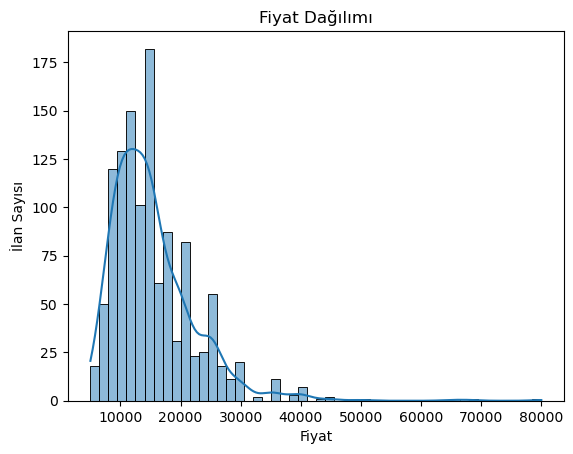

In [64]:
sns.histplot(data=df, x="Price", bins=50, kde=True)
plt.title("Fiyat Dağılımı")
plt.xlabel("Fiyat")
plt.ylabel("İlan Sayısı")
plt.show()

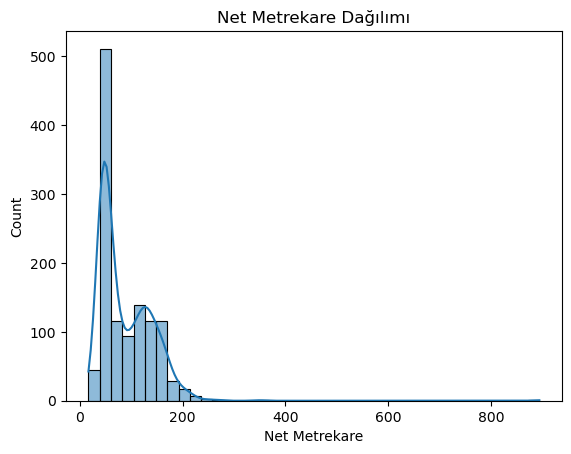

In [65]:
sns.histplot(data=df, x="Net Metrekare", bins=40, kde=True)
plt.title("Net Metrekare Dağılımı")
plt.show()

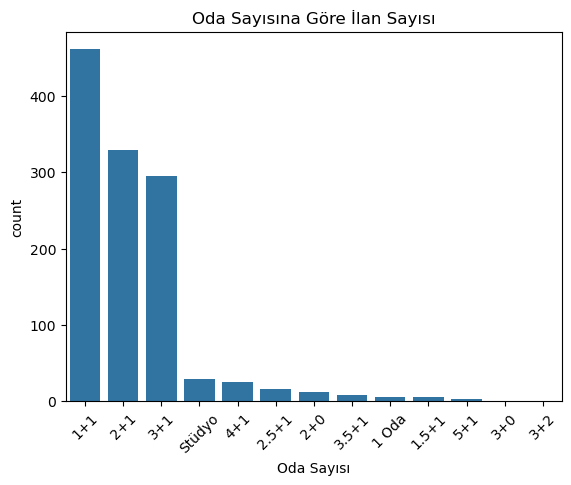

In [66]:
sns.countplot(data=df, x="Oda Sayısı", order=df["Oda Sayısı"].value_counts().index)
plt.title("Oda Sayısına Göre İlan Sayısı")
plt.xticks(rotation=45)
plt.show()

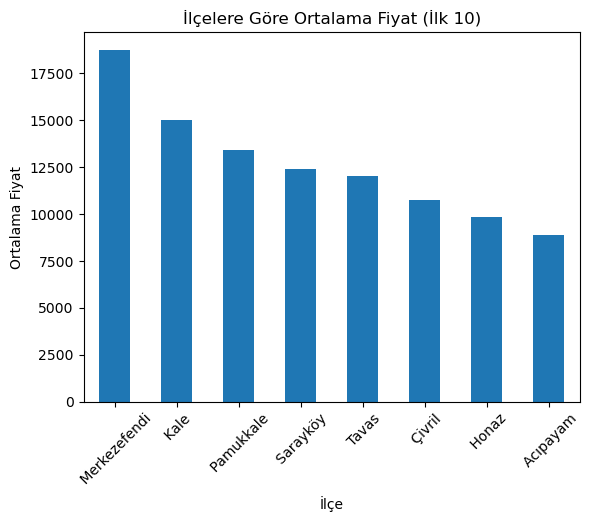

In [67]:
ilce_avg_price = df.groupby("İlçe")["Price"].mean().sort_values(ascending=False).head(10)
ilce_avg_price.plot(kind="bar")
plt.title("İlçelere Göre Ortalama Fiyat (İlk 10)")
plt.ylabel("Ortalama Fiyat")
plt.xticks(rotation=45)
plt.show()

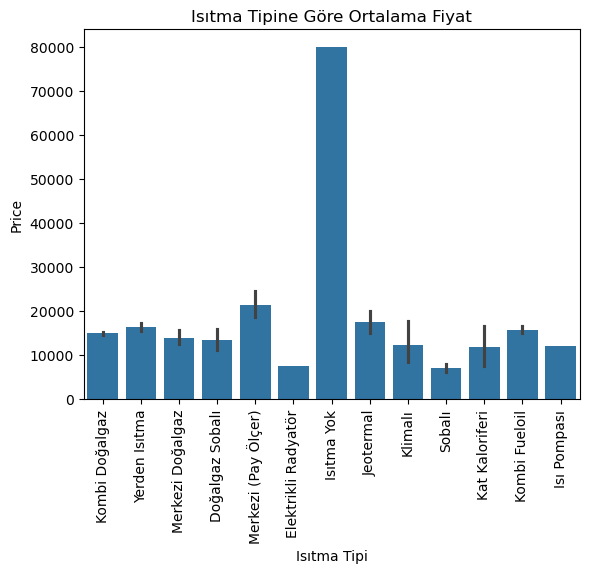

In [68]:
sns.barplot(data=df, x="Isıtma Tipi", y="Price", estimator='mean')
plt.title("Isıtma Tipine Göre Ortalama Fiyat")
plt.xticks(rotation=90)
plt.show()

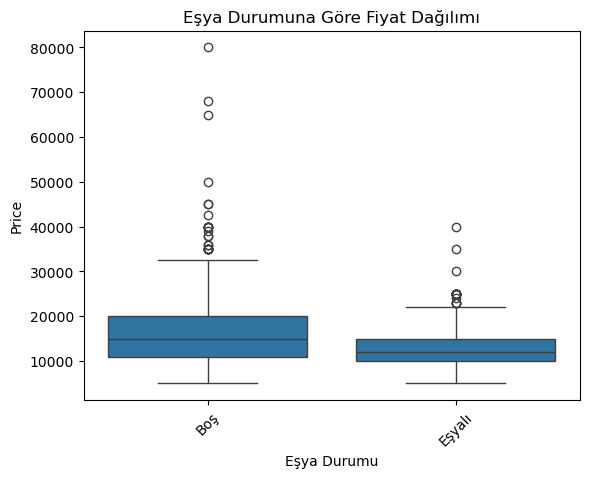

In [69]:
sns.boxplot(data=df, x="Eşya Durumu", y="Price")
plt.title("Eşya Durumuna Göre Fiyat Dağılımı")
plt.xticks(rotation=45)
plt.show()


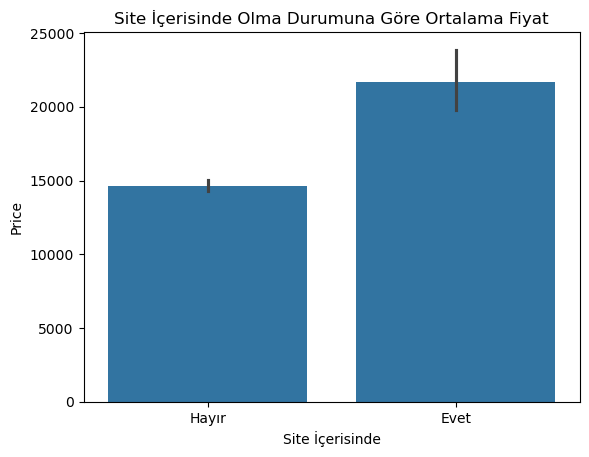

In [70]:
sns.barplot(data=df, x="Site İçerisinde", y="Price", estimator='mean')
plt.title("Site İçerisinde Olma Durumuna Göre Ortalama Fiyat")
plt.show()


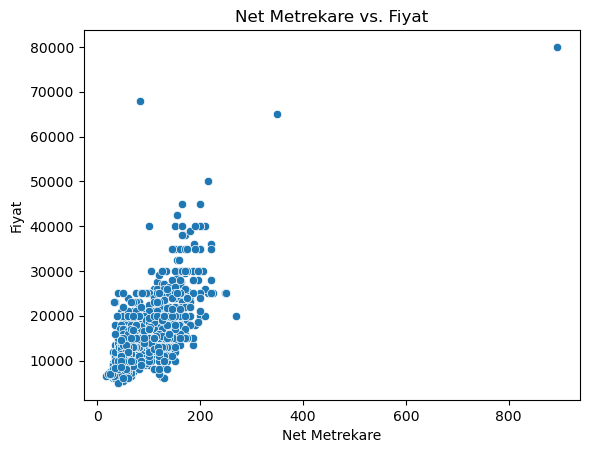

In [71]:
sns.scatterplot(data=df, x="Net Metrekare", y="Price")
plt.title("Net Metrekare vs. Fiyat")
plt.xlabel("Net Metrekare")
plt.ylabel("Fiyat")
plt.show()


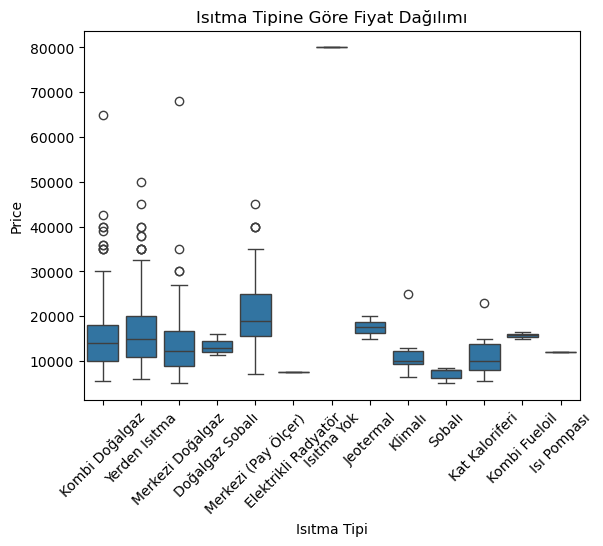

In [72]:
sns.boxplot(data=df, x="Isıtma Tipi", y="Price")
plt.title("Isıtma Tipine Göre Fiyat Dağılımı")
plt.xticks(rotation=45)
plt.show()

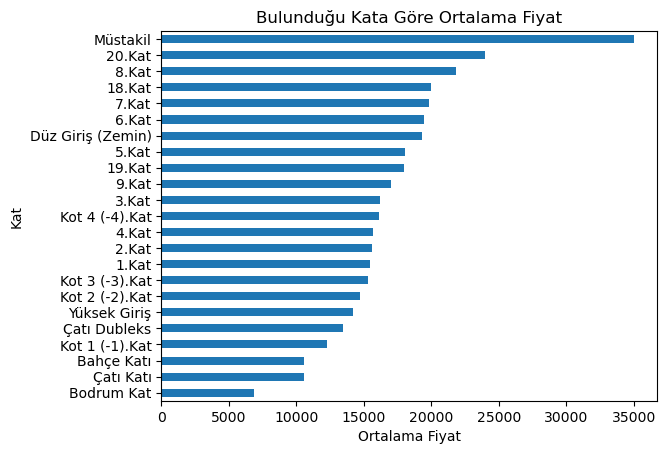

In [73]:
kat_fiyat = df.groupby("Bulunduğu Kat")["Price"].mean().sort_values()
kat_fiyat.plot(kind='barh')
plt.title("Bulunduğu Kata Göre Ortalama Fiyat")
plt.xlabel("Ortalama Fiyat")
plt.ylabel("Kat")
plt.show()

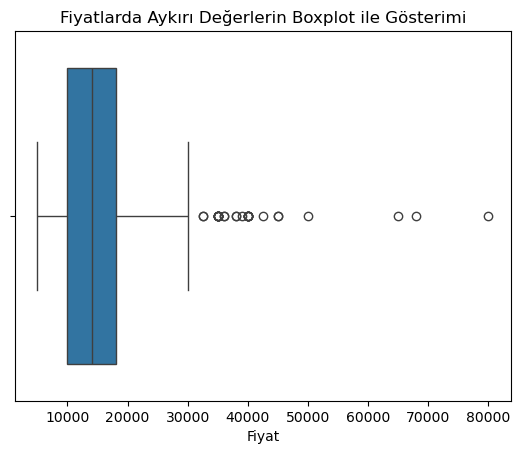

In [74]:
sns.boxplot(x=df["Price"])
plt.title("Fiyatlarda Aykırı Değerlerin Boxplot ile Gösterimi")
plt.xlabel("Fiyat")
plt.show()

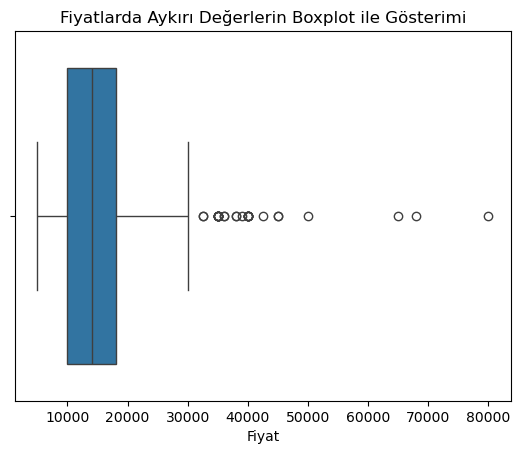

In [77]:
sns.boxplot(x=df["Price"])
plt.title("Fiyatlarda Aykırı Değerlerin Boxplot ile Gösterimi")
plt.xlabel("Fiyat")
plt.show()

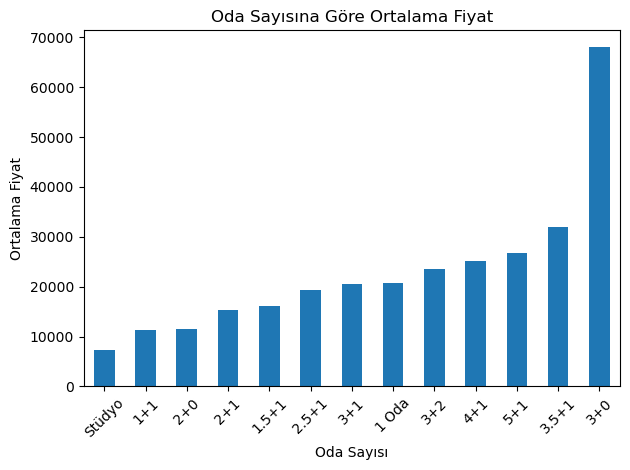

In [78]:
oda_fiyat = df.groupby("Oda Sayısı")["Price"].mean().sort_values()

oda_fiyat.plot(kind="bar")
plt.title("Oda Sayısına Göre Ortalama Fiyat")
plt.xlabel("Oda Sayısı")
plt.ylabel("Ortalama Fiyat")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
df.groupby("Oda Sayısı")["Price"].mean().sort_values()

Oda Sayısı
Stüdyo    7300.00
1+1      11395.66
2+0      11583.33
2+1      15312.30
1.5+1    16166.67
2.5+1    19343.75
3+1      20534.40
1 Oda    20758.33
3+2      23500.00
4+1      25100.00
5+1      26666.67
3.5+1    32055.56
3+0      68000.00
Name: Price, dtype: float64

In [80]:
df[df["Oda Sayısı"] == "3+0"]

,Unnamed: 0,İlan Numarası,Tipi,Net Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Eşya Durumu,Tapu Durumu,Site İçerisinde,Banyo Sayısı,Price,Balkon Sayısı,Balkon Tipi,WC Sayısı,İlandan sonra Geçen Gün,İlçe,Mahalle
99,99,17051024,Daire,83,3+0,16,Düz Giriş (Zemin),4,Merkezi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,68000,1,Açık Balkon,1,15,Pamukkale,Mehmetçik Mahallesi


In [81]:
df[df["Oda Sayısı"] == "1 Oda"]

,Unnamed: 0,İlan Numarası,Tipi,Net Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Eşya Durumu,Tapu Durumu,Site İçerisinde,Banyo Sayısı,Price,Balkon Sayısı,Balkon Tipi,WC Sayısı,İlandan sonra Geçen Gün,İlçe,Mahalle
98,98,17051448,Daire,894,1 Oda,0,Düz Giriş (Zemin),1,Isıtma Yok,Boş,Kat İrtifakı,Evet,Yok,80000,0,Yok,1,14,Merkezefendi,Bozburun Mahallesi
176,176,17005418,Daire,50,1 Oda,0,5.Kat,8,Yerden Isıtma,Eşyalı,Kat Mülkiyeti,Hayır,1,9550,0,Yok,1,2,Pamukkale,Deliktaş Mahallesi
286,286,16933368,Daire,50,1 Oda,0,1.Kat,3,Yerden Isıtma,Boş,Kat İrtifakı,Evet,1,15000,1,Kapalı Balkon,1,18,Pamukkale,Zeytinköy Mahallesi
733,733,16513663,Daire,30,1 Oda,5,Çatı Katı,3,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,7000,0,Yok,1,24,Pamukkale,Kınıklı Mahallesi
891,891,16411277,Daire,35,1 Oda,11,Çatı Katı,3,Merkezi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,1,6000,0,Yok,1,35,Pamukkale,Kınıklı Mahallesi
1143,1143,16013615,Daire,28,1 Oda,4,Bahçe Katı,3,Kombi Doğalgaz,Boş,Bilinmiyor,Hayır,1,7000,0,Yok,1,24,Pamukkale,Kınıklı Mahallesi


In [82]:
df[df["Oda Sayısı"] == "3.5+1"]

,Unnamed: 0,İlan Numarası,Tipi,Net Metrekare,Oda Sayısı,Binanın Yaşı,Bulunduğu Kat,Binanın Kat Sayısı,Isıtma Tipi,Eşya Durumu,Tapu Durumu,Site İçerisinde,Banyo Sayısı,Price,Balkon Sayısı,Balkon Tipi,WC Sayısı,İlandan sonra Geçen Gün,İlçe,Mahalle
115,115,17039497,Daire,200,3.5+1,5,4.Kat,14,Merkezi (Pay Ölçer),Boş,Kat Mülkiyeti,Evet,2,40000,0,Yok,1,16,Merkezefendi,Göveçlik Mahallesi
143,143,17026897,Daire,150,3.5+1,5,2.Kat,6,Merkezi (Pay Ölçer),Eşyalı,Kat Mülkiyeti,Evet,2,35000,0,Yok,1,18,Merkezefendi,Kayalar Mahallesi
152,152,17022133,Daire,220,3.5+1,16,3.Kat,4,Kombi Doğalgaz,Boş,Kat Mülkiyeti,Hayır,2,36000,2,Açık Balkon,3,2,Pamukkale,Kervansaray Mahallesi
837,837,16453829,Daire,220,3.5+1,5,3.Kat,9,Merkezi Doğalgaz,Boş,Kat Mülkiyeti,Evet,2,35000,0,Yok,1,95,Merkezefendi,Kayalar Mahallesi
919,919,16389482,Daire,150,3.5+1,5,2.Kat,3,Kombi Doğalgaz,Boş,Müstakil Tapulu,Hayır,2,26500,0,Yok,1,95,Merkezefendi,Gerzele Mahallesi
931,931,16376157,Daire,190,3.5+1,0,2.Kat,9,Yerden Isıtma,Boş,Kat İrtifakı,Evet,2,40000,0,Yok,1,95,Merkezefendi,Gültepe Mahallesi
1019,1019,16292365,Daire,140,3.5+1,5,3.Kat,3,Kombi Doğalgaz,Boş,Bilinmiyor,Hayır,1,18000,0,Yok,1,37,Merkezefendi,Akçeşme Mahallesi
1074,1074,16153478,Daire,185,3.5+1,4,3.Kat,5,Kombi Doğalgaz,Boş,Bilinmiyor,Hayır,2,28000,0,Yok,1,95,Merkezefendi,Adalet Mahallesi
1126,1126,16073912,Daire,170,3.5+1,5,5.Kat,5,Yerden Isıtma,Boş,Bilinmiyor,Evet,2,30000,0,Yok,1,95,Merkezefendi,Yenişafak Mahallesi


In [83]:
df = df[df["Oda Sayısı"] != "3+0"]

In [84]:
df = df[df["Oda Sayısı"] != "1 Oda"]
df = df[df["Oda Sayısı"] != "3.5+1"]

In [85]:
# Grafiğe göre özel sıralı liste
oda_sirasi = [
    "Stüdyo", "1+1", "2+0", "2+1", "1.5+1", "2.5+1", "3+1",
     "3+2", "4+1", "5+1"
]


# Sözlük oluştur: oda tipi → sıra indexi
oda_map = {oda: i for i, oda in enumerate(oda_sirasi)}

# Mapping uygula
df["Oda Sayısı"] = df["Oda Sayısı"].map(oda_map)

In [86]:
df["Oda Sayısı"].value_counts()

Oda Sayısı
1    461
3    329
6    295
0     29
8     25
5     16
2     12
4      6
9      3
7      1
Name: count, dtype: int64

In [87]:
df.drop("İlan Numarası", axis=1, inplace=True)

In [88]:
df.describe()

,Unnamed: 0,Net Metrekare,Oda Sayısı,Binanın Yaşı,Binanın Kat Sayısı,Price,Balkon Sayısı,WC Sayısı,İlandan sonra Geçen Gün
count,1177.00,1177.00,1177.00,1177.00,1177.00,1177.00,1177.00,1177.00,1177.00
mean,599.23,87.22,3.04,7.28,4.22,15154.63,0.18,1.03,46.13
std,344.93,47.21,2.18,6.11,2.84,6505.12,0.52,0.21,33.30
min,0.00,17.00,0.00,0.00,1.00,5000.00,0.00,1.00,0.00
25%,303.00,48.00,1.00,4.00,3.00,10000.00,0.00,1.00,21.00
50%,599.00,65.00,3.00,5.00,4.00,14000.00,0.00,1.00,35.00
75%,896.00,125.00,6.00,11.00,5.00,18000.00,0.00,1.00,85.00
max,1198.00,350.00,9.00,21.00,30.00,65000.00,3.00,4.00,95.00


In [89]:
corr = df.corr(numeric_only=True)

In [90]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['Unnamed: 0', 'Tipi', 'Net Metrekare', 'Oda Sayısı', 'Binanın Yaşı',
       'Bulunduğu Kat', 'Binanın Kat Sayısı', 'Isıtma Tipi', 'Eşya Durumu',
       'Tapu Durumu', 'Site İçerisinde', 'Banyo Sayısı', 'Price',
       'Balkon Sayısı', 'Balkon Tipi', 'WC Sayısı', 'İlandan sonra Geçen Gün',
       'İlçe', 'Mahalle'],
      dtype='object')>

<Axes: >

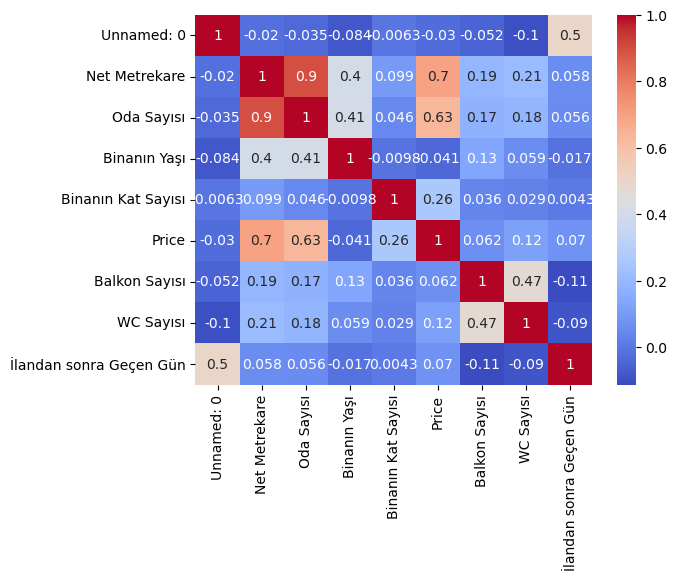

In [91]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

##### Label encoding ve deep learning için veri yetersiz olduğu için sentetik veri üretiyoruz

In [93]:
df.isnull().sum()

Unnamed: 0                 0
Tipi                       0
Net Metrekare              0
Oda Sayısı                 0
Binanın Yaşı               0
Bulunduğu Kat              0
Binanın Kat Sayısı         0
Isıtma Tipi                0
Eşya Durumu                0
Tapu Durumu                0
Site İçerisinde            0
Banyo Sayısı               0
Price                      0
Balkon Sayısı              0
Balkon Tipi                0
WC Sayısı                  0
İlandan sonra Geçen Gün    0
İlçe                       0
Mahalle                    0
dtype: int64

In [94]:
df.shape

(1177, 19)

In [95]:
# Deep Learning Modeli için veri yetersiz olduğu için mevcut dataFrame uygun olacak şekilde yeni veriler üretiyoruz
import pandas as pd
import numpy as np


numeric_cols = ['Net Metrekare', 'Oda Sayısı', 'Binanın Yaşı', 
                'Banyo Sayısı', 'Balkon Sayısı', 'WC Sayısı', 'Price']

# Dönüştürme
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [96]:
df.isnull().sum()

Unnamed: 0                 0
Tipi                       0
Net Metrekare              0
Oda Sayısı                 0
Binanın Yaşı               0
Bulunduğu Kat              0
Binanın Kat Sayısı         0
Isıtma Tipi                0
Eşya Durumu                0
Tapu Durumu                0
Site İçerisinde            0
Banyo Sayısı               2
Price                      0
Balkon Sayısı              0
Balkon Tipi                0
WC Sayısı                  0
İlandan sonra Geçen Gün    0
İlçe                       0
Mahalle                    0
dtype: int64

In [97]:
# numeric_cols sütunlarında NaN içeren satırları silelim
df.dropna(subset=numeric_cols, inplace=True)

In [98]:

n_augments = 2

noise_settings = {
    'Net Metrekare': 5,
    'Oda Sayısı': 0.2,        
    'Binanın Yaşı': 1,
    'Banyo Sayısı': 0.1,
    'Balkon Sayısı': 0.1,
    'WC Sayısı': 0.1,
    'Price': 0.05  # Price için %5
}

augmented_rows = []

for idx, row in df.iterrows():
    for i in range(n_augments):
        new_row = row.copy()
        for col in numeric_cols:
            if col == 'Price':
                noise = np.random.normal(0, noise_settings[col] * row[col])
            else:
                noise = np.random.normal(0, noise_settings[col])
            new_row[col] = row[col] + noise
            
            # tam sayı alması gerek sütunları yuvarlayalım
            if col in ['Oda Sayısı', 'Banyo Sayısı', 'Balkon Sayısı', 'WC Sayısı']:
                new_row[col] = int(round(new_row[col]))
        augmented_rows.append(new_row)

# Augmented verileri DataFrame'e dönüştür
df_augmented = pd.DataFrame(augmented_rows)

# Eski ve yeni verileri birleştiriyoruz
df = pd.concat([df, df_augmented], ignore_index=True)

# Sonuç
print("Yapay üretilen veri sayısı:", df_augmented.shape[0])
print("Toplam veri sayısı:", df.shape[0])



Yapay üretilen veri sayısı: 2350
Toplam veri sayısı: 3525


### Modelling

In [100]:
x=df.drop("Price", axis=1)
y=df[["Price"]]

In [101]:
# One-hot Coding
x= pd.get_dummies(x, drop_first=True)

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [103]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

#### Linear Regression

In [105]:
LR = LinearRegression()
LR.fit(x_train, y_train)
LR_pred = LR.predict(x_test)

# Performans metrikleri
lr_mse = mean_squared_error(y_test, LR_pred)
lr_r2 = r2_score(y_test, LR_pred)

print("=== Linear Regression ===")
print(f"MSE: {lr_mse:.2f}")
print(f"R^2: {lr_r2:.4f}\n")

=== Linear Regression ===
MSE: 10844883.28
R^2: 0.7248



### Lasso

In [107]:
L = Lasso(random_state=42)
L.fit(x_train, y_train)
L_pred = L.predict(x_test)

# Performans metrikleri
lasso_mse = mean_squared_error(y_test, L_pred)
lasso_r2 = r2_score(y_test, L_pred)

print("=== Lasso ===")
print(f"MSE: {lasso_mse:.2f}")
print(f"R^2: {lasso_r2:.4f}\n")

=== Lasso ===
MSE: 10873394.82
R^2: 0.7241



### Ridge

In [109]:
R = Ridge(random_state=42)
R.fit(x_train, y_train)
R_pred = R.predict(x_test)

# Performans metrikleri
R_mse = mean_squared_error(y_test, R_pred)
R_r2 = r2_score(y_test, R_pred)

print("=== Ridge ===")
print(f"MSE: {R_mse:.2f}")
print(f"R^2: {R_r2:.4f}\n")

=== Ridge ===
MSE: 10878832.39
R^2: 0.7240



### ElasticNet

In [111]:
EN = ElasticNet(random_state=42)
EN.fit(x_train, y_train)
EN_pred = EN.predict(x_test)

# Performans metrikleri
EN_mse = mean_squared_error(y_test, LR_pred)
EN_r2 = r2_score(y_test, EN_pred)

print("=== ElasticNet ===")
print(f"MSE: {EN_mse:.2f}")
print(f"R^2: {EN_r2:.4f}\n")

=== ElasticNet ===
MSE: 10844883.28
R^2: 0.6098



### XGBRegressor

In [113]:
xgb = XGBRegressor(random_state=42)
xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)

# Performans metrikleri
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("=== XGBRegressor ===")
print(f"MSE: {xgb_mse:.2f}")
print(f"R^2: {xgb_r2:.4f}\n")

=== XGBRegressor ===
MSE: 3004392.95
R^2: 0.9238



### Gradient Boosting

In [115]:
GB = GradientBoostingRegressor(random_state=42)
GB.fit(x_train, y_train)
GB_pred = GB.predict(x_test)

# Performans metrikleri
GB_mse = mean_squared_error(y_test, GB_pred)
GB_r2 = r2_score(y_test, GB_pred)

print("=== Gradient Boosting ===")
print(f"MSE: {GB_mse:.2f}")
print(f"R^2: {GB_r2:.4f}\n")

=== Gradient Boosting ===
MSE: 9052901.17
R^2: 0.7703



### Random Forest

In [117]:
RF = RandomForestRegressor(n_estimators=100, random_state=42)
RF.fit(x_train, y_train)
RF_pred = RF.predict(x_test)

# Performans metrikleri
RF_mse = mean_squared_error(y_test, RF_pred)
RF_r2 = r2_score(y_test, RF_pred)

print("=== Random Forest ===")
print(f"MSE: {RF_mse:.2f}")
print(f"R^2: {RF_r2:.4f}\n")

=== Random Forest ===
MSE: 3751013.46
R^2: 0.9048

